In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns

In [11]:
%matplotlib inline

In [12]:
df = pd.read_csv("../data/index/dataset_index_with_split.csv")

In [13]:
df.columns

Index(['patch_id', 'tile_id', 'country', 'aoi_id', 'row_off', 'col_off',
       'patch_size', 'stride', 'spectral_path', 'label_path', 'valid_frac',
       'cloud_frac', 'unique_classes', 'dominant_class', 'dominant_frac',
       'is_usable', 'acq_start', 'acq_end', 'mosaic_method', 'center_x',
       'center_y', 'group_id', 'split'],
      dtype='object')

In [14]:
# explore number of usable (valid_frac > 0.9 and cloud_frac < 0.1) patches
df["is_usable"].value_counts()

is_usable
False    144928
True      57572
Name: count, dtype: int64

In [15]:
(df["valid_frac"] == 1).all()

np.True_

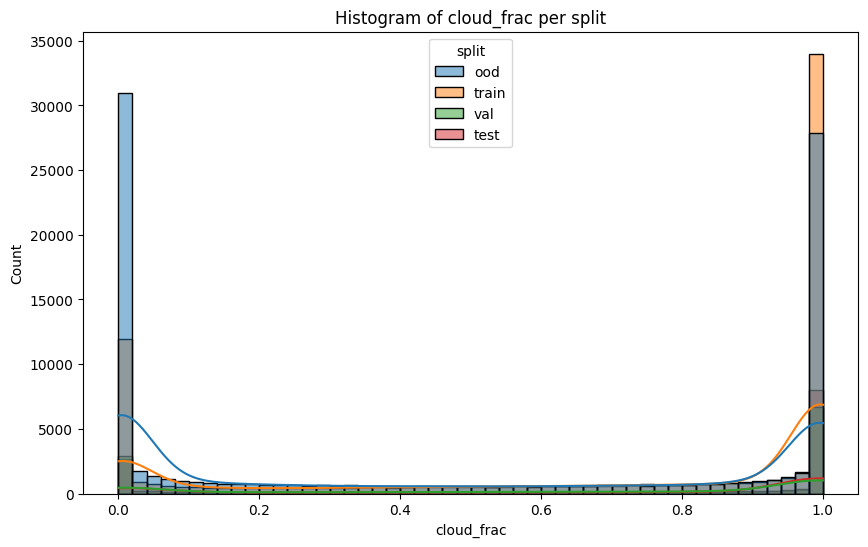

In [16]:
# Cloud Fraction per split
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="cloud_frac", hue="split", bins=50, kde=True)
plt.title("Histogram of cloud_frac per split")
plt.show()

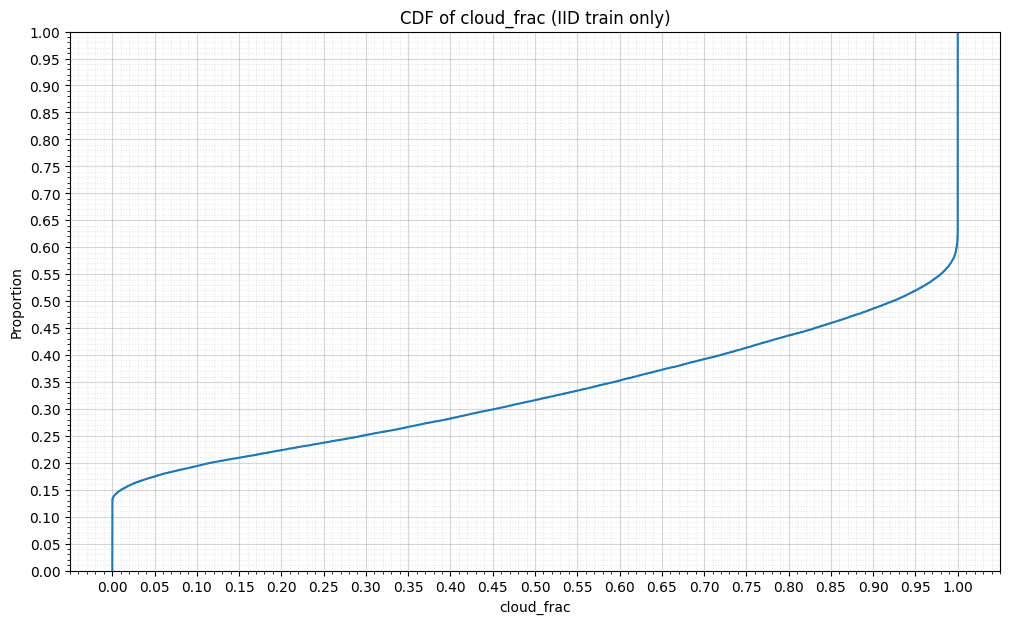

In [17]:
# CDF of cloud_frac for IID train only with increased granularity
plt.figure(figsize=(12, 7))
sns.ecdfplot(data=df[df["split"] == "train"], x="cloud_frac")
plt.title("CDF of cloud_frac (IID train only)")
# Increase detail in scales
plt.xticks(np.arange(0, 1.05, 0.05))
plt.yticks(np.arange(0, 1.05, 0.05))
# Add grid and minor ticks for even more detail
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.minorticks_on()
plt.grid(True, which="minor", ls=":", alpha=0.3)
plt.show()

In [18]:
# Map WorldCover class names
CLASS_NAMES = {
    10: "Trees",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare / sparse",
    70: "Snow/Ice",
    80: "Water",
    90: "Wetland",
    95: "Mangroves",
    100: "Moss/Lichen",
}

cloud_frac_candidates = [0.1, 0.15, 0.2]
df_cloud_frac = dict()
df_train = df[df["split"] == "train"].copy()
df_train["class_name"] = df_train["dominant_class"].map(CLASS_NAMES)

baseline_total_pixels = df_train.size

baseline_per_class = df_train.groupby("class_name").size().rename("baseline_patches")

results = []

for cloud_frac in cloud_frac_candidates:
    df_cloud_frac = df_train[df_train["cloud_frac"] <= cloud_frac].copy()
    retained_total = df_cloud_frac.size
    total_retention_pct = 100.0 * retained_total / baseline_total_pixels
    retained_per_class = df_cloud_frac.groupby("class_name").size().rename("retained_patches")

    comparison = baseline_per_class.to_frame().join(retained_per_class, how="left").fillna(0)

    comparison["retention_pct"] = (
        100.0 * comparison["retained_patches"] / comparison["baseline_patches"]
    )

    results.append(
        {
            "threshold": cloud_frac,
            "total_retained_patches": retained_total,
            "total_retention_pct": total_retention_pct,
            "per_class": comparison.sort_values("retention_pct"),
        }
    )

for r in results:
    print(
        f"cloud_frac={r['threshold']:.2f} | "
        f"Total retained: {r['total_retention_pct']:.1f}% "
        f"({r['total_retained_patches']:,} patches)"
    )

for r in results:
    print(f"\n=== Cloud threshold cloud_frac = {r['threshold']:.2f} ===")
    display(
        r["per_class"].round(1).style.background_gradient(cmap="Reds", subset=["retention_pct"])
    )

cloud_frac=0.10 | Total retained: 19.4% (351,840 patches)
cloud_frac=0.15 | Total retained: 20.9% (379,560 patches)
cloud_frac=0.20 | Total retained: 22.3% (405,336 patches)

=== Cloud threshold cloud_frac = 0.10 ===


,baseline_patches,retained_patches,retention_pct
class_name,,,
Moss/Lichen,1,0.000000,0.000000
Snow/Ice,31,0.000000,0.000000
Bare / sparse,170,19.000000,11.200000
Built-up,1414,247.000000,17.500000
Trees,32803,5775.000000,17.600000
Grassland,13705,2415.000000,17.600000
Cropland,25836,5622.000000,21.800000
Water,1396,475.000000,34.000000
Shrubland,147,62.000000,42.200000



=== Cloud threshold cloud_frac = 0.15 ===


,baseline_patches,retained_patches,retention_pct
class_name,,,
Moss/Lichen,1,0.000000,0.000000
Snow/Ice,31,0.000000,0.000000
Bare / sparse,170,19.000000,11.200000
Built-up,1414,264.000000,18.700000
Trees,32803,6203.000000,18.900000
Grassland,13705,2616.000000,19.100000
Cropland,25836,6115.000000,23.700000
Water,1396,485.000000,34.700000
Shrubland,147,66.000000,44.900000



=== Cloud threshold cloud_frac = 0.20 ===


,baseline_patches,retained_patches,retention_pct
class_name,,,
Moss/Lichen,1,0.000000,0.000000
Snow/Ice,31,0.000000,0.000000
Bare / sparse,170,19.000000,11.200000
Built-up,1414,277.000000,19.600000
Trees,32803,6655.000000,20.300000
Grassland,13705,2805.000000,20.500000
Cropland,25836,6518.000000,25.200000
Water,1396,501.000000,35.900000
Shrubland,147,67.000000,45.600000


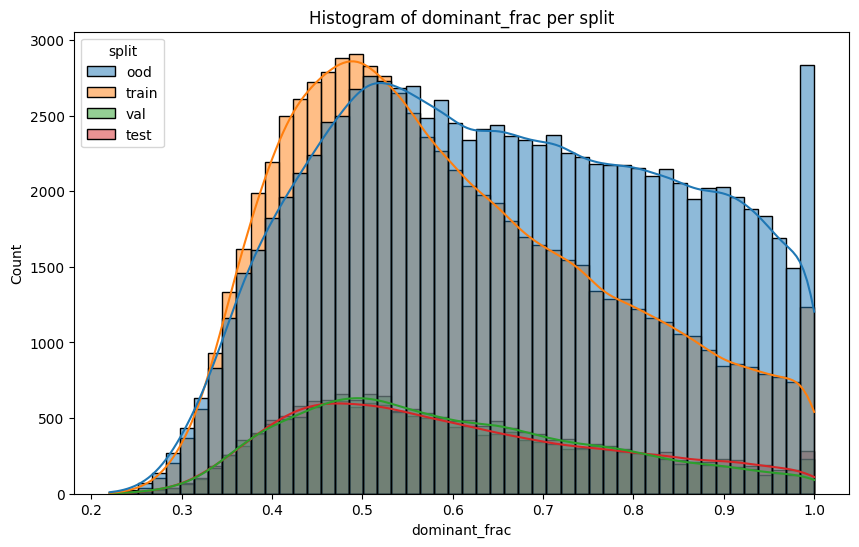

In [19]:
# Dominant Class Fraction per split
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="dominant_frac", hue="split", bins=50, kde=True)
plt.title("Histogram of dominant_frac per split")
plt.show()

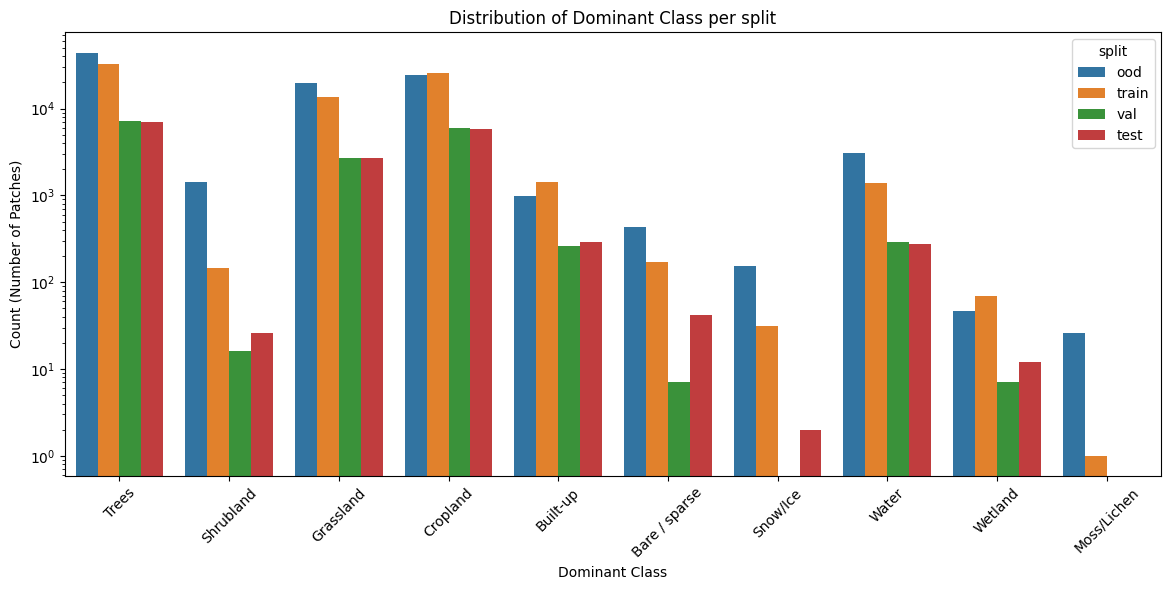

In [20]:
# Dominant Class per split

# Create a temporary column for mapping IDs to names for the plot
df_temp = df.copy()
df_temp["class_name"] = df_temp["dominant_class"].map(CLASS_NAMES)

plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_temp,
    x="class_name",
    hue="split",
    order=[
        CLASS_NAMES[k]
        for k in sorted(CLASS_NAMES.keys())
        if CLASS_NAMES[k] in df_temp["class_name"].unique()
    ],
)
plt.title("Distribution of Dominant Class per split")
plt.xticks(rotation=45)
plt.ylabel("Count (Number of Patches)")
plt.xlabel("Dominant Class")
plt.tight_layout()
plt.yscale("log")
plt.show()

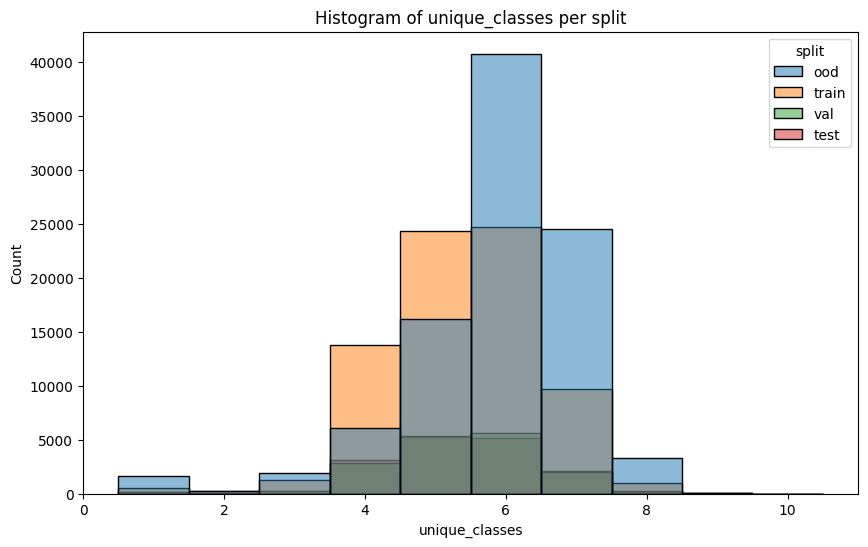

In [21]:
# Unique Classes per split
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="unique_classes", hue="split", bins=20, discrete=True)
plt.title("Histogram of unique_classes per split")
plt.show()

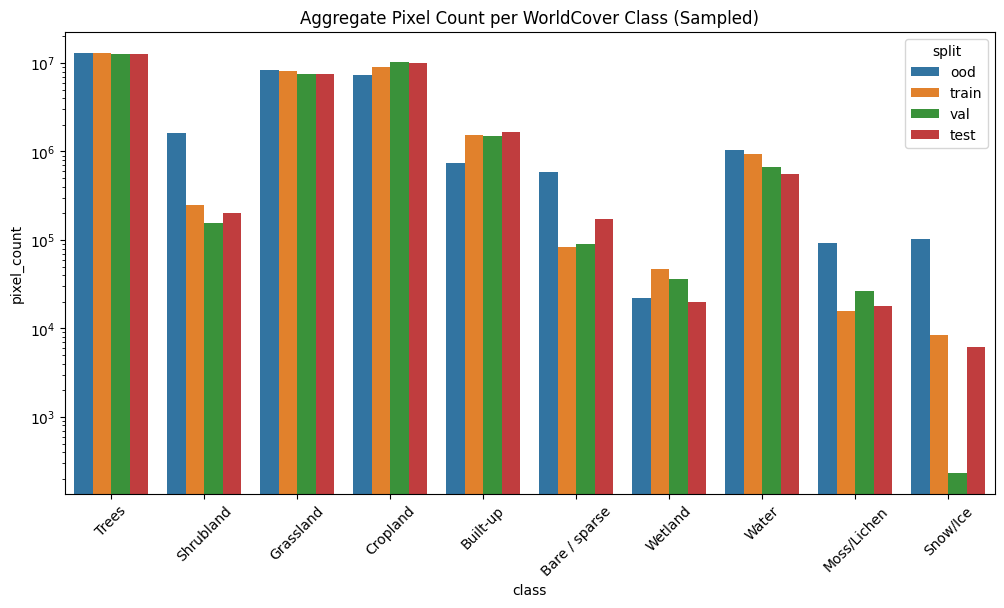

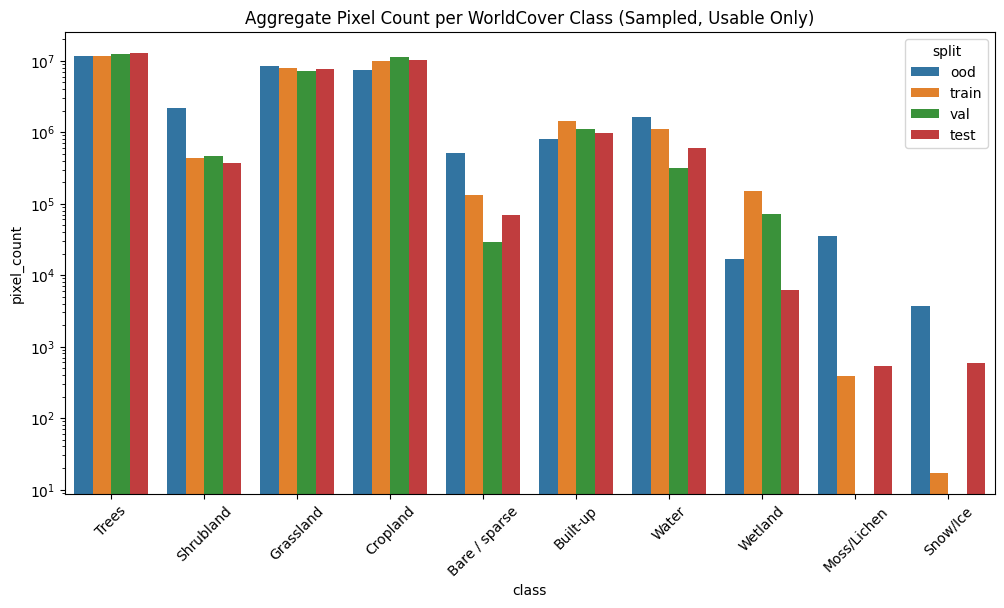

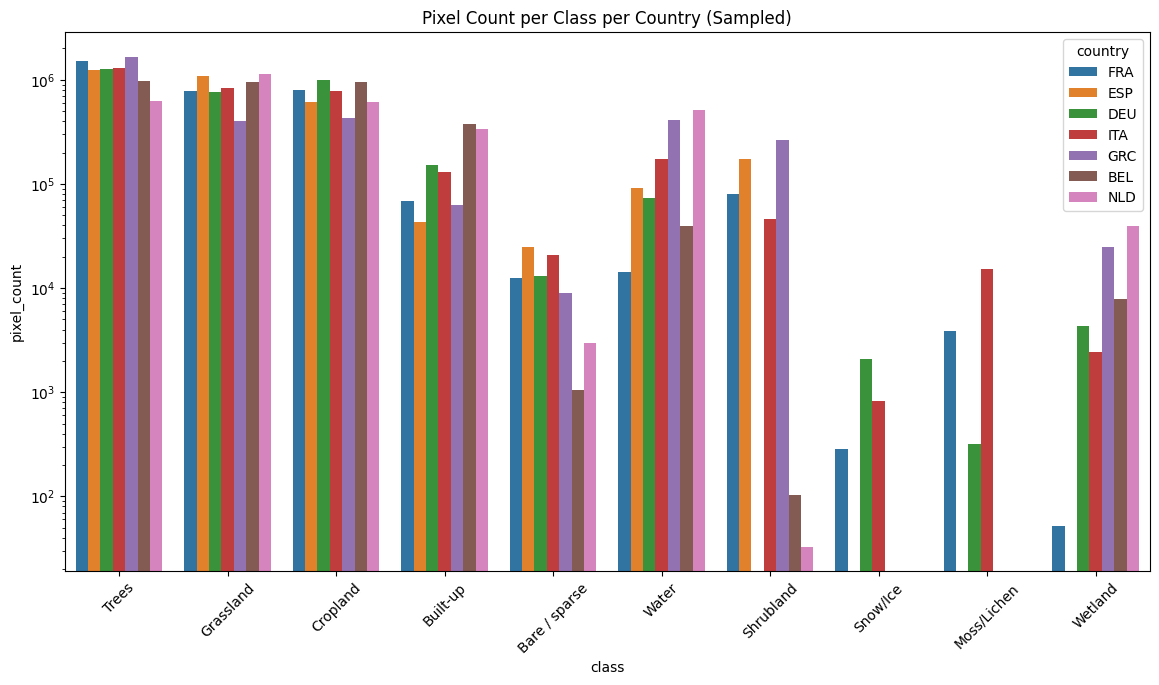

In [22]:
from collections import Counter


def get_pixel_counts(subset_df, sample_size=500):
    """Estimate pixel counts by sampling patches."""
    total_counts = Counter()
    sample = subset_df.sample(min(len(subset_df), sample_size), random_state=42)

    for _, row in sample.iterrows():
        try:
            # Paths are relative to repo root, notebook is in notebooks/
            with rasterio.open("../" + row["label_path"]) as src:
                data = src.read(1)
                unique, counts = np.unique(data, return_counts=True)
                for u, c in zip(unique, counts, strict=False):
                    if u in CLASS_NAMES:
                        total_counts[CLASS_NAMES[u]] += c
        except Exception:
            continue
    return total_counts


splits = df["split"].unique()
split_stats = []
split_stats_usable = []
for split in splits:
    counts = get_pixel_counts(df[df["split"] == split])
    counts_usable = get_pixel_counts(df[(df["split"] == split) & df["is_usable"]])
    for cls, cnt in counts.items():
        split_stats.append({"split": split, "class": cls, "pixel_count": cnt})
    for cls, cnt in counts_usable.items():
        split_stats_usable.append({"split": split, "class": cls, "pixel_count": cnt})

stats_df = pd.DataFrame(split_stats)
stats_df_usable = pd.DataFrame(split_stats_usable)

plt.figure(figsize=(12, 6))
sns.barplot(data=stats_df, x="class", y="pixel_count", hue="split")
plt.title("Aggregate Pixel Count per WorldCover Class (Sampled)")
plt.xticks(rotation=45)
plt.yscale("log")
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=stats_df_usable, x="class", y="pixel_count", hue="split")
plt.title("Aggregate Pixel Count per WorldCover Class (Sampled, Usable Only)")
plt.xticks(rotation=45)
plt.yscale("log")
plt.show()


top_countries = df["country"].value_counts().head(10).index.tolist()
country_stats = []
for country in top_countries:
    counts = get_pixel_counts(df[df["country"] == country], sample_size=50)
    for cls, cnt in counts.items():
        country_stats.append({"country": country, "class": cls, "pixel_count": cnt})

country_stats_df = pd.DataFrame(country_stats)
plt.figure(figsize=(14, 7))
sns.barplot(data=country_stats_df, x="class", y="pixel_count", hue="country")
plt.title("Pixel Count per Class per Country (Sampled)")
plt.xticks(rotation=45)
plt.yscale("log")
plt.show()

In [23]:
# Sample a subset of usable patches
usable_df = df[df["is_usable"]]
sample_size = min(len(usable_df), 1000)
sample_df = usable_df.sample(sample_size, random_state=42)

band_names = ["B02 (Blue)", "B03 (Green)", "B04 (Red)", "B08 (NIR)"]
spectral_stats = []

print(f"Calculating spectral stats for {len(sample_df)} patches...")

for b_idx in range(1, 5):  # 1-based indexing for rasterio bands
    all_band_values = []
    total_pixels = 0
    zero_count = 0
    nan_count = 0

    for _, row in sample_df.iterrows():
        try:
            with rasterio.open("../" + row["spectral_path"]) as src:
                data = src.read(b_idx).astype(float)

                total_pixels += data.size
                zero_count += np.sum(data == 0)
                nan_count += np.sum(np.isnan(data))

                # Sub-sample pixels for percentile calculation (speed)
                valid_data = data[~np.isnan(data) & (data != 0)]
                if valid_data.size > 0:
                    # Sample up to 100 pixels per patch
                    pixel_sample = np.random.choice(valid_data, min(valid_data.size, 100))
                    all_band_values.extend(pixel_sample)
        except Exception:
            continue

    if all_band_values:
        all_band_values = np.array(all_band_values)
        spectral_stats.append(
            {
                "Band": band_names[b_idx - 1],
                "Min": np.min(all_band_values),
                "Max": np.max(all_band_values),
                "1st Pct": np.percentile(all_band_values, 1),
                "99th Pct": np.percentile(all_band_values, 99),
                "% Zeros": (zero_count / total_pixels) * 100 if total_pixels > 0 else 0,
                "% NaNs": (nan_count / total_pixels) * 100 if total_pixels > 0 else 0,
            }
        )

if spectral_stats:
    stats_df = pd.DataFrame(spectral_stats)
    print("\nSpectral Sanity Check Results:")
    print(stats_df.to_string(index=False))
else:
    print("\nNo spectral data found or error reading files.")

Calculating spectral stats for 1000 patches...

Spectral Sanity Check Results:
       Band    Min    Max  1st Pct  99th Pct  % Zeros  % NaNs
 B02 (Blue) 0.0002 1.3568   0.0078  0.195800 0.393404     0.0
B03 (Green) 0.0003 1.2512   0.0101  0.246800 0.369873     0.0
  B04 (Red) 0.0001 1.6456   0.0031  0.312400 0.878864     0.0
  B08 (NIR) 0.0001 1.5736   0.0023  0.502801 0.965521     0.0


In [24]:
# Verify Split Invariant: each tile_id appears in exactly one split
tile_split_counts = df.groupby("tile_id")["split"].nunique()
violation_count = (tile_split_counts > 1).sum()

if violation_count == 0:
    print("Every tile_id belongs to exactly one split (no tile-level leakage).")
else:
    print(f"ERROR: Found {violation_count} tiles assigned to multiple splits!")
    print("Tiles with multiple split assignments:")
    print(tile_split_counts[tile_split_counts > 1])

Every tile_id belongs to exactly one split (no tile-level leakage).
